<center>
    <img src="http://sct.inf.utfsm.cl/wp-content/uploads/2020/04/logo_di.png" style="width:40%">
    <h2> ILI-140 - Taller de Programación </h2>
    <h2> Caso anomalias en cañerías</h2>
    <h3> Grupo Butify </h3>
    <h3> 08/07/2025 </h3>
</center>

##### Integrantes
Nicolas Horta  
Nicolas Olivos  
Benjamin Pavez  
Ariel Pulgar  
Gabriel Saez  

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.express as px
import hdbscan
from ipywidgets import interact, FloatSlider

In [ ]:
# 1. Cargar el dataset
dfKmeans = pd.read_excel("anomalia.xlsx")

# 2. Seleccionar variables de sensores

# Columnas de "water_leak_detection_1000_rows"
#X = dfKmeans[['Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)']]

# Columnas de "anomalia"
X = dfKmeans[['caudal', 'presion', 'temperatura']]

# 3. Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Evaluación de KMeans en rango de K = 2 a 8
k_values = list(range(2, 9))
eval_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)

    eval_results.append({
        'k': k,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })

# 5. Convertir resultados a DataFrame y elegir el mejor K
df_eval = pd.DataFrame(eval_results).sort_values(by='silhouette', ascending=False)
print("Mejores configuraciones según Silhouette Score:")
print(df_eval.head())

# 6. Volver a entrenar KMeans con el mejor K
best_k = df_eval.iloc[0]['k']
kmeans = KMeans(n_clusters=int(best_k), random_state=42)
dfKmeans['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# 7. Visualización con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
dfKmeans['PCA1'], dfKmeans['PCA2'] = X_pca[:, 0], X_pca[:, 1]

Mejores configuraciones según Silhouette Score:
   k  silhouette  davies_bouldin  calinski_harabasz
0  2    0.593539        0.459779         480.888806
6  8    0.298351        1.008977         582.187357
2  4    0.296065        1.004108         570.955152
5  7    0.293635        0.998527         564.007857
3  5    0.291366        0.998898         549.749544


Graficos de metricas de evaluacion


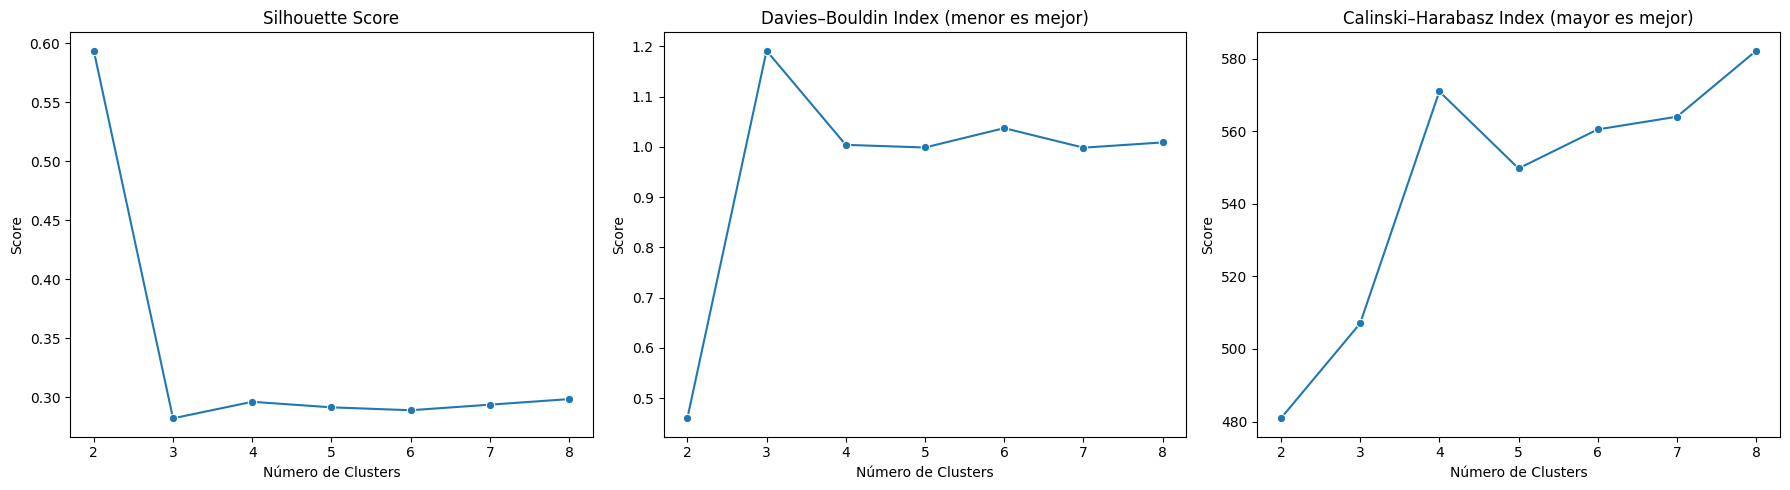

In [ ]:
# Graficos de metricas de evaluacion
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=df_eval, x='k', y='silhouette', marker='o', ax=axs[0])
axs[0].set_title("Silhouette Score")
axs[0].set_xlabel("Número de Clusters")
axs[0].set_ylabel("Score")

sns.lineplot(data=df_eval, x='k', y='davies_bouldin', marker='o', ax=axs[1])
axs[1].set_title("Davies–Bouldin Index (menor es mejor)")
axs[1].set_xlabel("Número de Clusters")
axs[1].set_ylabel("Score")

sns.lineplot(data=df_eval, x='k', y='calinski_harabasz', marker='o', ax=axs[2])
axs[2].set_title("Calinski–Harabasz Index (mayor es mejor)")
axs[2].set_xlabel("Número de Clusters")
axs[2].set_ylabel("Score")

plt.tight_layout()
plt.show()

Graficos de cluster KMeans con el mejor K

In [ ]:
fig = px.scatter_3d(
    dfKmeans,
    x='presion',
    y='caudal',
    z='temperatura',
    color_discrete_sequence=px.colors.qualitative.Plotly,
    opacity=0.8,
    hover_data=['caudal', 'presion', 'temperatura', 'fecha']
)
fig.update_traces(
    marker=dict(
        size=3,
        sizemode='diameter',
    )
)
fig.update_layout(
    scene=dict(
        xaxis_title='presion',
        yaxis_title='caudal',
        zaxis_title='temperatura'
    )
)
fig.show()

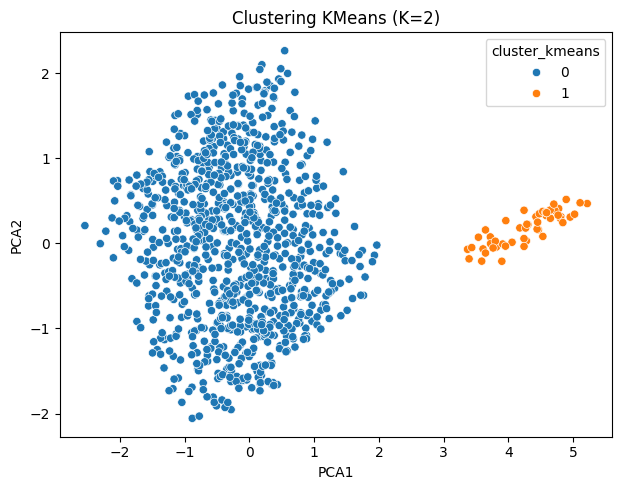

In [ ]:
# Graficos de clusters
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=dfKmeans, x='PCA1', y='PCA2', hue='cluster_kmeans', palette='tab10')
plt.title(f'Clustering KMeans (K={int(best_k)})')

plt.tight_layout()
plt.show()

In [ ]:
dfKmeans.head(4)

,fecha,edificio_id,activo_id,caudal,presion,temperatura,cluster_kmeans,PCA1,PCA2
0,2025-05-22 02:23:18,EDIF001,CAN001,38.55,4.33,14.1,0,-0.013046,1.810887
1,2025-05-22 02:18:18,EDIF001,CAN001,35.34,1.78,28.1,0,0.040895,-1.012100
2,2025-05-22 02:13:18,EDIF001,CAN001,38.09,1.24,17.8,0,1.138515,-0.722201
3,2025-05-22 02:08:18,EDIF001,CAN001,16.82,1.96,29.5,0,-0.870669,-1.204206


In [ ]:
dfKmeans['Falla'] = (dfKmeans['cluster_kmeans'] == 1).astype(int)

In [ ]:
dfKmeans.head(4)

,fecha,edificio_id,activo_id,caudal,presion,temperatura,cluster_kmeans,PCA1,PCA2,Falla
0,2025-05-22 02:23:18,EDIF001,CAN001,38.55,4.33,14.1,0,-0.013046,1.810887,0
1,2025-05-22 02:18:18,EDIF001,CAN001,35.34,1.78,28.1,0,0.040895,-1.012100,0
2,2025-05-22 02:13:18,EDIF001,CAN001,38.09,1.24,17.8,0,1.138515,-0.722201,0
3,2025-05-22 02:08:18,EDIF001,CAN001,16.82,1.96,29.5,0,-0.870669,-1.204206,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedShuffleSplit

# Columnas de "water_leak_detection_1000_rows"
#features = ['Flow Rate (L/s)', 'Pressure (bar)', 'Temperature (°C)', 'cluster_kmeans']

# Columnas de "anomalia" (comentadas porque no estamos usando ese dataset)
features = ['caudal', 'presion', 'temperatura']

X = dfKmeans[features]
y = dfKmeans['Falla']

# Inicializamos el splitter 80% train, 20% restante (val + test)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(sss1.split(dfKmeans, y))

# Dividir entre entrenamiento y (validación + test)
df_train = dfKmeans.iloc[train_idx]
df_temp = dfKmeans.iloc[temp_idx]

# Ahora dividir el 20% restante en 10/10 (valid/test = 50/50 del temp)
y_temp = df_temp['cluster_kmeans']
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(sss2.split(df_temp, y_temp))

df_val = df_temp.iloc[val_idx]
df_test = df_temp.iloc[test_idx]

# Verificación
print("Train set:", df_train.shape)
print("Validation set:", df_val.shape)
print("Test set:", df_test.shape)

# Verificar proporciones por cluster
print("\nCluster distribution in Train:")
print(df_train['cluster_kmeans'].value_counts(normalize=True))

print("\nCluster distribution in Validation:")
print(df_val['cluster_kmeans'].value_counts(normalize=True))

print("\nCluster distribution in Test:")
print(df_test['cluster_kmeans'].value_counts(normalize=True))


Train set: (800, 10)
Validation set: (100, 10)
Test set: (100, 10)

Cluster distribution in Train:
cluster_kmeans
0    0.95
1    0.05
Name: proportion, dtype: float64

Cluster distribution in Validation:
cluster_kmeans
0    0.95
1    0.05
Name: proportion, dtype: float64

Cluster distribution in Test:
cluster_kmeans
0    0.95
1    0.05
Name: proportion, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Características utilizadas para el modelo (puedes extenderlas)
feature_cols = ['caudal', 'presion', 'temperatura']
target_col = 'cluster_kmeans'

X_val = df_val[features]
y_val = df_val[target_col]

X_test = df_test[feature_cols]
y_test = df_test[target_col]

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Modelo Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

# Resultados
print("Random Forest:\n", classification_report(y_test, y_pred_rf))
print("Naive Bayes:\n", classification_report(y_test, y_pred_nb))

Random Forest:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Naive Bayes:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
# RANDOM FOREST evaluacion

# --- Evaluación en TEST ---
y_test_pred = rf.predict(X_train)
test_accuracy = accuracy_score(y_train, y_test_pred)
print(f"Accuracy on TEST set: {test_accuracy:.4f}")
print("\nClassification Report (TEST):")
print(classification_report(y_train, y_test_pred))

# --- Evaluación en VALIDACIÓN ---
y_val_pred = rf.predict(X_test)
val_accuracy = accuracy_score(y_test, y_val_pred)
print(f"\nAccuracy on VALIDATION set: {val_accuracy:.4f}")
print("\nClassification Report (VALIDATION):")
print(classification_report(y_test, y_val_pred))

Accuracy on TEST set: 1.0000

Classification Report (TEST):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       760
           1       1.00      1.00      1.00        40

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


Accuracy on VALIDATION set: 1.0000

Classification Report (VALIDATION):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
# Evaluacion de Naive Bayes

y_test_pred = nb.predict(X_train)
test_accuracy = accuracy_score(y_train, y_test_pred)
print(f"Accuracy on TEST set: {test_accuracy:.4f}")
print("\nClassification Report (TEST):")
print(classification_report(y_train, y_test_pred))

# --- Evaluación en VALIDACIÓN ---
y_val_pred = nb.predict(X_test)
val_accuracy = accuracy_score(y_test, y_val_pred)
print(f"\nAccuracy on VALIDATION set: {val_accuracy:.4f}")
print("\nClassification Report (VALIDATION):")
print(classification_report(y_test, y_val_pred))

Accuracy on TEST set: 1.0000

Classification Report (TEST):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       760
           1       1.00      1.00      1.00        40

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800


Accuracy on VALIDATION set: 1.0000

Classification Report (VALIDATION):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Selección de características
feature_cols = ['caudal', 'presion', 'temperatura']
X_train = df_train[feature_cols]
y_train = df_train['cluster_kmeans']
X_val = df_val[feature_cols]
y_val = df_val['cluster_kmeans']
X_test = df_test[feature_cols]
y_test = df_test['cluster_kmeans']


# Entrenar modelos
rf_model = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)
nb_model = GaussianNB().fit(X_train, y_train)

# Métricas macro promedio
rf_metrics = precision_recall_fscore_support(y_test, rf_model.predict(X_test), average='macro')
nb_metrics = precision_recall_fscore_support(y_test, nb_model.predict(X_test), average='macro')

# Crear DataFrame resumen
results = pd.DataFrame({
    'Model': ['Random Forest', 'Naive Bayes'],
    'Precision': [rf_metrics[0], nb_metrics[0]],
    'Recall': [rf_metrics[1], nb_metrics[1]],
    'F1 Score': [rf_metrics[2], nb_metrics[2]]
})

print("🔎 Comparación de modelos supervisados:")
print(results)

🔎 Comparación de modelos supervisados:
           Model  Precision  Recall  F1 Score
0  Random Forest        1.0     1.0       1.0
1    Naive Bayes        1.0     1.0       1.0


In [ ]:
nuevo_punto = pd.DataFrame([{
    'caudal': 79.92,
    'presion': 0.44,
    'temperatura': 2.6
}])

# Clasificar con ambos modelos
pred_rf = rf.predict(nuevo_punto)
pred_nb = nb.predict(nuevo_punto)

print(f"Random Forest predice: {'Anomalía' if pred_rf[0] == 1 else 'Normal'}")
print(f"Naive Bayes predice: {'Anomalía' if pred_nb[0] == 1 else 'Normal'}")

Random Forest predice: Anomalía
Naive Bayes predice: Anomalía


DBSCAN con epsilon variable



Top 10 combinaciones con al menos 2 clústeres y menor % de outliers:
     eps  min_samples  n_clusters  n_outliers  outlier_percent
24  0.57            5           2           0              0.0
25  0.57            7           2           0              0.0
26  0.57            9           2           0              0.0
27  0.57           11           2           0              0.0
23  0.57            3           2           0              0.0
58  0.84           19           2           0              0.0
57  0.84           17           2           0              0.0
60  0.93            5           2           0              0.0
55  0.84           13           2           0              0.0
54  0.84           11           2           0              0.0


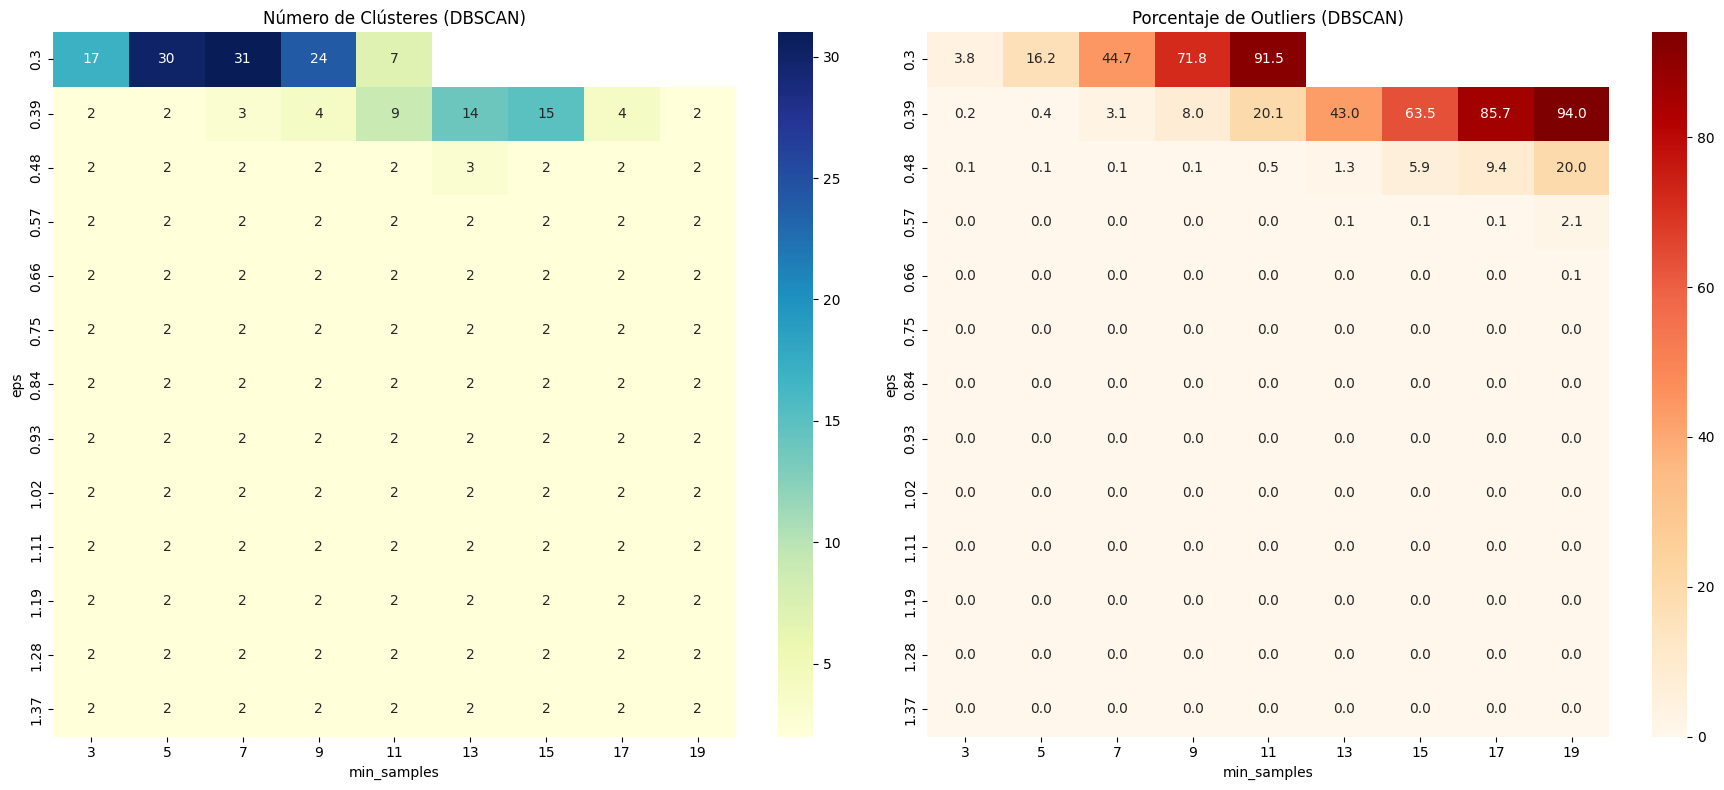

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# --- 1. Con el dataframe "anomalia" ---
features =['caudal', 'presion', 'temperatura']
df = pd.read_excel("anomalia.xlsx")[features].dropna()

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# --- 2. RANGO DE PARÁMETROS A PROBAR ---
eps_values = np.round(np.linspace(0.3, 2.0, 20), 2)  # Ajusta el rango según tu escala
min_samples_values = list(range(3, 20, 2))  # Valores razonables para tus datos

# --- 3. EVALUACIÓN DE COMBINACIONES ---
resultados = []

for eps in eps_values:
    for min_samples in min_samples_values:
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        if n_clusters >= 2:
            n_outliers = np.sum(labels == -1)
            total_points = len(labels)
            perc_outliers = round((n_outliers / total_points) * 100, 2)

            resultados.append({
                'eps': eps,
                'min_samples': min_samples,
                'n_clusters': n_clusters,
                'n_outliers': n_outliers,
                'outlier_percent': perc_outliers
            })

# --- 4. TABLA DE RESULTADOS ---
df_resultados = pd.DataFrame(resultados)
df_sorted = df_resultados.sort_values(by='outlier_percent')

print("\nTop 10 combinaciones con al menos 2 clústeres y menor % de outliers:")
print(df_sorted.head(10))

#best_k = df_eval.iloc[0]['k']
#kmeans = KMeans(n_clusters=int(best_k), random_state=42)
#df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

best_epsilon = df_sorted.iloc[0]['eps']
best_samples = df_sorted.iloc[0]['min_samples']

# --- 5. HEATMAPS ---
pivot_clusters = df_resultados.pivot(index='eps', columns='min_samples', values='n_clusters')
pivot_outliers = df_resultados.pivot(index='eps', columns='min_samples', values='outlier_percent')

fig, axs = plt.subplots(1, 2, figsize=(18, 8))

sns.heatmap(pivot_clusters, annot=True, fmt=".0f", cmap='YlGnBu', ax=axs[0])
axs[0].set_title("Número de Clústeres (DBSCAN)")
axs[0].set_xlabel("min_samples")
axs[0].set_ylabel("eps")

sns.heatmap(pivot_outliers, annot=True, fmt=".1f", cmap='OrRd', ax=axs[1])
axs[1].set_title("Porcentaje de Outliers (DBSCAN)")
axs[1].set_xlabel("min_samples")
axs[1].set_ylabel("eps")

plt.tight_layout()
plt.show()


In [ ]:
# DBSCAN clustering
dbscan = DBSCAN(eps=best_epsilon, min_samples=int(best_samples))
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'], df['PCA2'] = X_pca[:, 0], X_pca[:, 1]

Text(0.5, 1.0, 'Clustering DBSCAN (epsilon=0.57)')

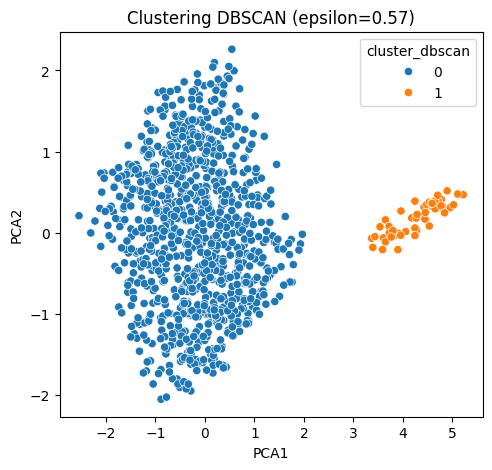

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='cluster_dbscan', palette='tab10')
plt.title(f'Clustering DBSCAN (epsilon={float(best_epsilon)})')


In [ ]:
df['Anomalia'] = (df['cluster_dbscan'] == 1).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

# Suponiendo que 'Anomalia' es tu pseudoetiqueta (1 = anomalía, 0 = normal)
X = df[['caudal', 'presion', 'temperatura']]
y = df['Anomalia']

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

RF (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import make_pipeline

#rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
#rf_model.fit(X_train, y_train)

rf_model = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42))
rf_model.fit(X_train, y_train)

# Predicción y evaluación
y_pred_rf = rf_model.predict(X_test)

print("----- RANDOM FOREST -----")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


----- RANDOM FOREST -----
[[190   0]
 [  0  10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



NB (Naive Bayes)

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import make_pipeline

#nb_model = GaussianNB()
#nb_model.fit(X_train, y_train)

nb_model = make_pipeline(StandardScaler(), GaussianNB())
nb_model.fit(X_train, y_train)

# Predicción y evaluación
y_pred_nb = nb_model.predict(X_test)

print("----- NAIVE BAYES -----")
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))


----- NAIVE BAYES -----
[[190   0]
 [  0  10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       190
           1       1.00      1.00      1.00        10

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



Clasificar nuevo dato

In [ ]:
nuevo_punto = pd.DataFrame([{
    'caudal': 79.92,
    'presion': 0.44,
    'temperatura': 2.6
}])

# Clasificar con ambos modelos
pred_rf = rf_model.predict(nuevo_punto)
pred_nb = nb_model.predict(nuevo_punto)

print(f"Random Forest predice: {'Anomalía' if pred_rf[0] == 1 else 'Normal'}")
print(f"Naive Bayes predice: {'Anomalía' if pred_nb[0] == 1 else 'Normal'}")

Random Forest predice: Anomalía
Naive Bayes predice: Anomalía


In [ ]:
nuevo_punto = pd.DataFrame([{
    'caudal': 79.92,
    'presion': 0.4,
    'temperatura': 20
}])

# Clasificar con ambos modelos
pred_rf = rf_model.predict(nuevo_punto)
pred_nb = nb_model.predict(nuevo_punto)

print(f"Random Forest predice: {'Anomalía' if pred_rf[0] == 1 else 'Normal'}")
print(f"Naive Bayes predice: {'Anomalía' if pred_nb[0] == 1 else 'Normal'}")

Random Forest predice: Anomalía
Naive Bayes predice: Normal


In [ ]:
# Escalamos los datos
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler().fit(X)
pca     = PCA(n_components=2).fit(scaler.transform(X))

# 2. Transform del dataset
X_scaled = scaler.transform(X)
X_pca    = pca.transform(X_scaled)

# 3. Transform del nuevo punto
nuevo_p_scaled = scaler.transform(nuevo_punto)
nuevo_p_pca    = pca.transform(nuevo_p_scaled)

In [ ]:
print(X.mean())
print("Nuevo punto:", nuevo_punto)

caudal         32.36793
presion         2.63192
temperatura    21.52660
dtype: float64
Nuevo punto:    caudal  presion  temperatura
0   79.92      0.4           20


In [ ]:
def actualizar_pca(caudal, presion, temperatura):
    # 1) Prepara el nuevo punto y transforma
    df_nuevo = pd.DataFrame([{
        'caudal':      caudal,
        'presion':     presion,
        'temperatura': temperatura
    }])
    p_scaled    = scaler.transform(df_nuevo)
    p_pca       = pca.transform(p_scaled)

    # 2) Redibuja el scatter
    plt.clf()  # limpia la figura
    plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1],
                c='green', label='Normal', alpha=0.6)
    plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1],
                c='red',   label='Anómalo', alpha=0.6)
    plt.scatter(p_pca[0, 0], p_pca[0, 1],
                c='blue', s=120, edgecolors='black',
                label='Nuevo Punto')

    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.title('Nuevo punto en espacio PCA')
    plt.legend()
    plt.grid(True)
    plt.draw()



interact(
    actualizar_pca,
    caudal      = FloatSlider(min=0,   max=100, step=1,   value= X['caudal'].mean(),      description='Caudal'),
    presion     = FloatSlider(min=0,   max=10,  step=0.1, value= X['presion'].mean(),    description='Presión'),
    temperatura = FloatSlider(min=0,   max=50,  step=1,   value= X['temperatura'].mean(), description='Temperatura')
)

interactive(children=(FloatSlider(value=32.36793, description='Caudal', step=1.0), FloatSlider(value=2.63192, …

<function __main__.actualizar_pca(caudal, presion, temperatura)>

**Por alguna razon, RF siempre detecta que un punto es anomalo y NB, siempre detecta que el punto es normal**

### HDBSCAN

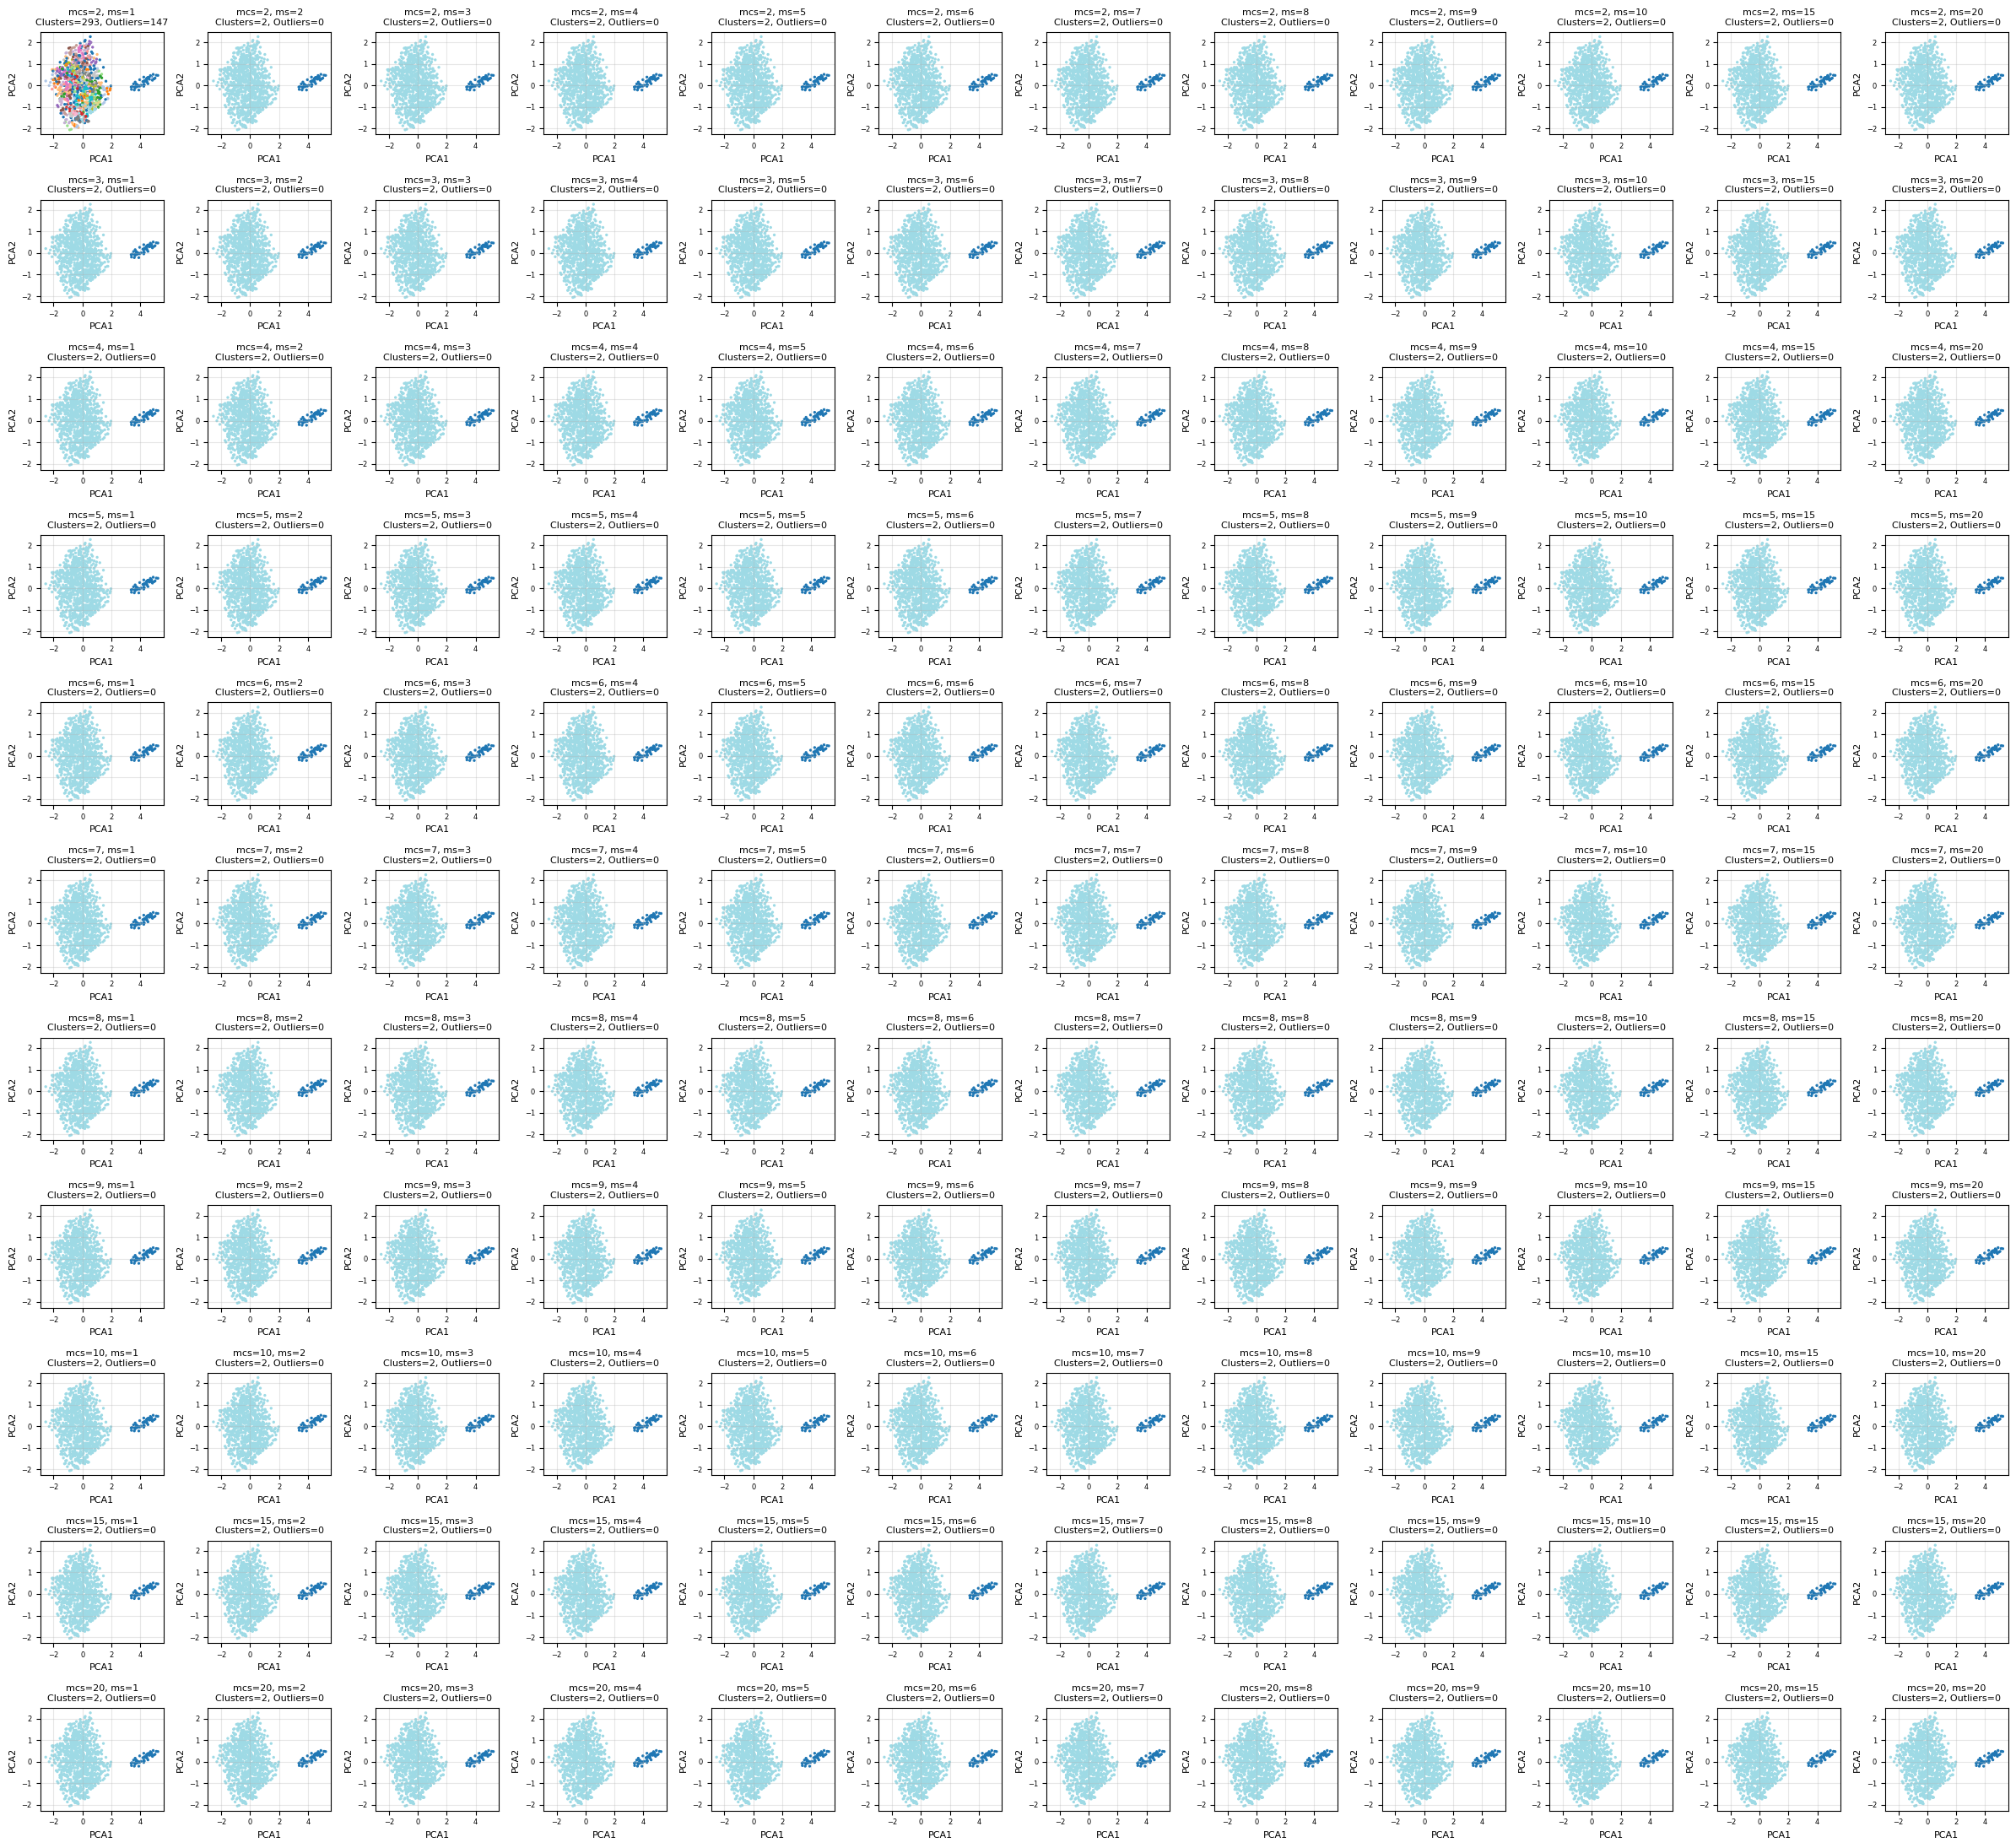

Top 10 mejores configuraciones HDBSCAN (menor % de outliers):
    min_cluster_size  min_samples  n_clusters  n_outliers  outlier_percent
1                  2            2           2           0              0.0
2                  2            3           2           0              0.0
3                  2            4           2           0              0.0
4                  2            5           2           0              0.0
6                  2            7           2           0              0.0
5                  2            6           2           0              0.0
7                  2            8           2           0              0.0
8                  2            9           2           0              0.0
12                 3            1           2           0              0.0
9                  2           10           2           0              0.0


In [ ]:
import hdbscan
import warnings
warnings.filterwarnings("ignore")

# Cargar datos
df_hdbscan = pd.read_excel("anomalia.xlsx")
features_hdbscan = ['caudal', 'presion', 'temperatura']
X_hdbscan = df_hdbscan[features_hdbscan].dropna()

# Escalar coordenadas
scaler_hdbscan = StandardScaler()
X_hdbscan_scaled = scaler_hdbscan.fit_transform(X_hdbscan)

# Parámetros a probar
min_cluster_sizes = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
min_samples_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]

# Crear figura con subplots
n_combinations = len(min_cluster_sizes) * len(min_samples_values)
cols = 12  # Número de columnas
rows = (n_combinations + cols - 1) // cols  # Calcular filas necesarias

fig, axs = plt.subplots(rows, cols, figsize=(24, rows * 2))
axs = axs.flatten()  # Convertir a array 1D para facilitar indexación

# Aplicar PCA para visualización
pca_viz = PCA(n_components=2)
X_hdbscan_pca_viz = pca_viz.fit_transform(X_hdbscan_scaled)

# Guardar resultados
hdbscan_results = []

for i, mcs in enumerate(min_cluster_sizes):
    for j, msp in enumerate(min_samples_values):
        clusterer = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=msp, cluster_selection_method='eom')
        labels = clusterer.fit_predict(X_hdbscan_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_outliers = np.sum(labels == -1)
        perc_outliers = (n_outliers / len(labels)) * 100

        # Guardar resultados
        hdbscan_results.append({
            'min_cluster_size': mcs,
            'min_samples': msp,
            'n_clusters': n_clusters,
            'n_outliers': n_outliers,
            'outlier_percent': perc_outliers
        })

        # Graficar usando PCA
        idx = i * len(min_samples_values) + j
        if idx < len(axs):
            axs[idx].scatter(X_hdbscan_pca_viz[:, 0], X_hdbscan_pca_viz[:, 1], c=labels, cmap='tab20', s=2)
            axs[idx].set_title(f"mcs={mcs}, ms={msp}\nClusters={n_clusters}, Outliers={n_outliers}", fontsize=8)
            axs[idx].set_xlabel("PCA1", fontsize=8)
            axs[idx].set_ylabel("PCA2", fontsize=8)
            axs[idx].grid(True, alpha=0.3)
            axs[idx].tick_params(labelsize=6)

# Ocultar subplots vacíos
for idx in range(len(hdbscan_results), len(axs)):
    axs[idx].set_visible(False)

plt.tight_layout()
plt.show()

# Crear tabla resumen
df_hdbscan_results = pd.DataFrame(hdbscan_results)
df_hdbscan_sorted = df_hdbscan_results.sort_values(by='outlier_percent')

print("Top 10 mejores configuraciones HDBSCAN (menor % de outliers):")
print(df_hdbscan_sorted.head(10))

# Exportar a CSV
df_hdbscan_results.to_csv("hdbscan_summary_Hyper.csv", index=False)

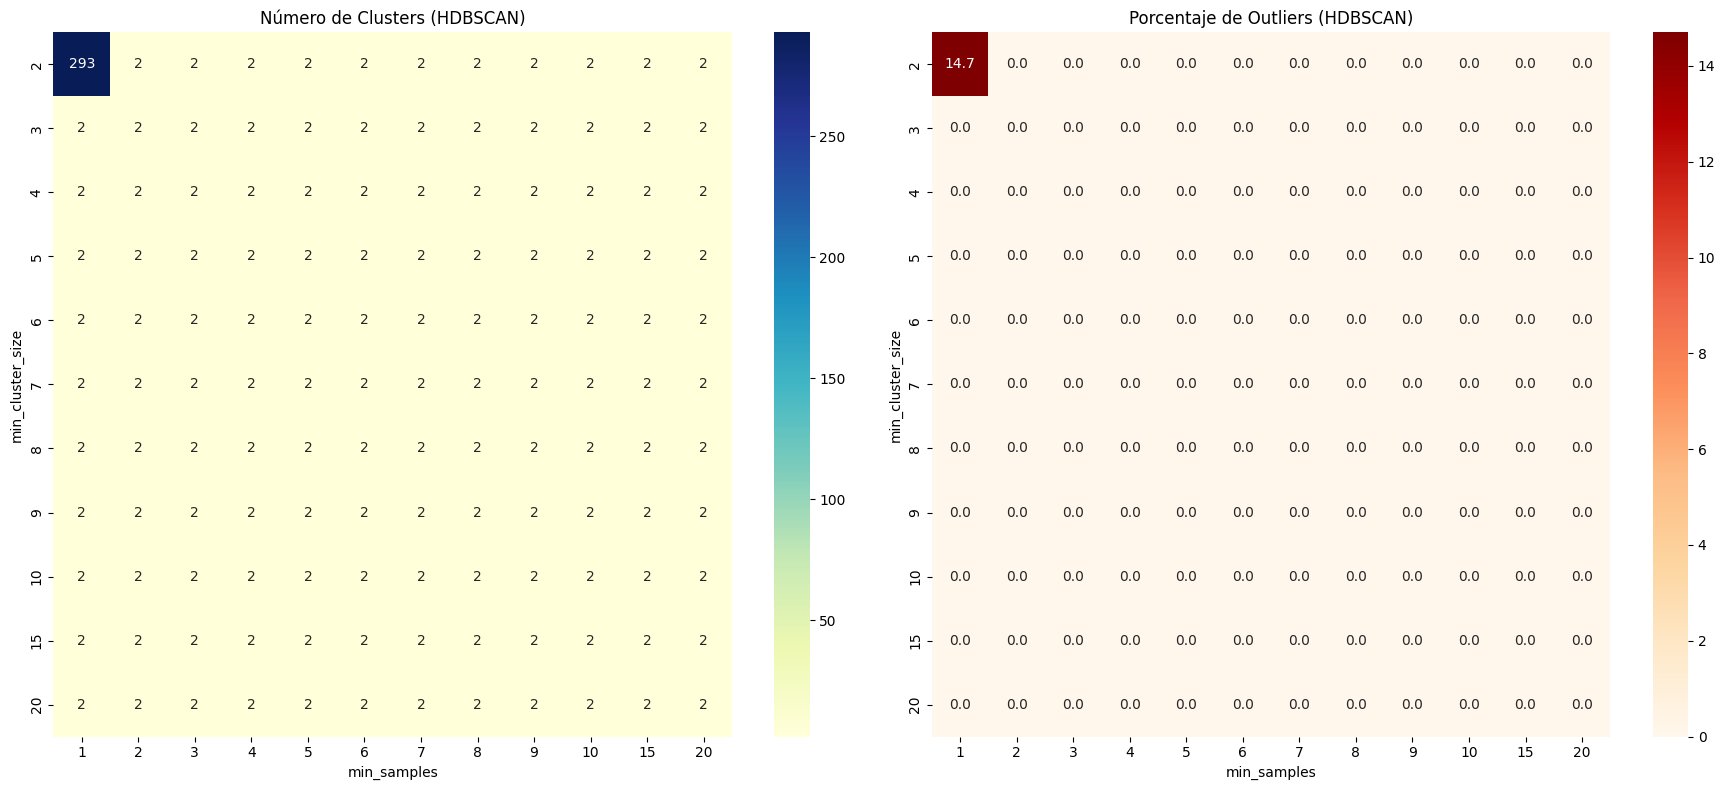

In [ ]:
# Crear heatmaps para HDBSCAN
pivot_clusters_hdb = df_hdbscan_results.pivot(index='min_cluster_size', columns='min_samples', values='n_clusters')
pivot_outliers_hdb = df_hdbscan_results.pivot(index='min_cluster_size', columns='min_samples', values='outlier_percent')

fig, axs = plt.subplots(1, 2, figsize=(18, 8))

# Heatmap de número de clusters
sns.heatmap(pivot_clusters_hdb, annot=True, fmt=".0f", cmap='YlGnBu', ax=axs[0])
axs[0].set_title("Número de Clusters (HDBSCAN)")
axs[0].set_xlabel("min_samples")
axs[0].set_ylabel("min_cluster_size")

# Heatmap de porcentaje de outliers
sns.heatmap(pivot_outliers_hdb, annot=True, fmt=".1f", cmap='OrRd', ax=axs[1])
axs[1].set_title("Porcentaje de Outliers (HDBSCAN)")
axs[1].set_xlabel("min_samples")
axs[1].set_ylabel("min_cluster_size")

plt.tight_layout()
plt.show()

Mejores parámetros HDBSCAN:
min_cluster_size: 2
min_samples: 2


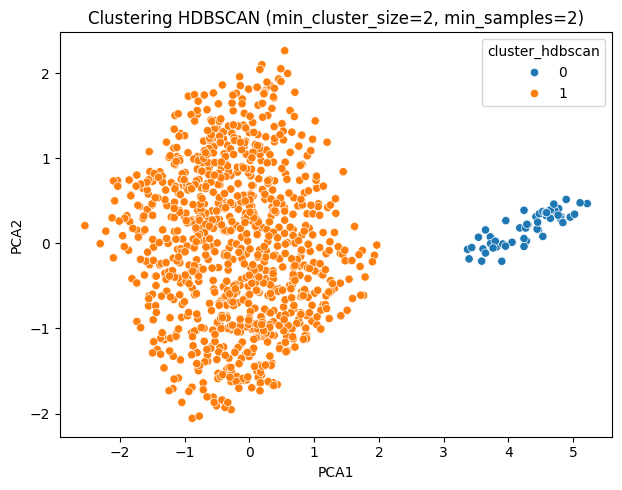


Estadísticas HDBSCAN:
Número de clusters: 2
Número de outliers: 0
Porcentaje de outliers: 0.00%


In [ ]:
# Aplicar HDBSCAN con los mejores parámetros
best_min_cluster_size = int(df_hdbscan_sorted.iloc[0]['min_cluster_size'])
best_min_samples_hdb = int(df_hdbscan_sorted.iloc[0]['min_samples'])

print(f"Mejores parámetros HDBSCAN:")
print(f"min_cluster_size: {best_min_cluster_size}")
print(f"min_samples: {best_min_samples_hdb}")

# Aplicar clustering con mejores parámetros
hdbscan_best = hdbscan.HDBSCAN(
    min_cluster_size=best_min_cluster_size,
    min_samples=best_min_samples_hdb,
    cluster_selection_method='eom'
)
df_hdbscan['cluster_hdbscan'] = hdbscan_best.fit_predict(X_hdbscan_scaled)

# Aplicar PCA para visualización
pca_hdb = PCA(n_components=2)
X_hdbscan_pca = pca_hdb.fit_transform(X_hdbscan_scaled)
df_hdbscan['PCA1_hdb'], df_hdbscan['PCA2_hdb'] = X_hdbscan_pca[:, 0], X_hdbscan_pca[:, 1]

# Visualización
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_hdbscan, x='PCA1_hdb', y='PCA2_hdb', hue='cluster_hdbscan', palette='tab10')
plt.title(f'Clustering HDBSCAN (min_cluster_size={best_min_cluster_size}, min_samples={best_min_samples_hdb})')
plt.xlabel('PCA1')
plt.ylabel('PCA2')

plt.tight_layout()
plt.show()

# Estadísticas del clustering
n_clusters_hdb = len(set(df_hdbscan['cluster_hdbscan'])) - (1 if -1 in df_hdbscan['cluster_hdbscan'].values else 0)
n_outliers_hdb = np.sum(df_hdbscan['cluster_hdbscan'] == -1)
print(f"\nEstadísticas HDBSCAN:")
print(f"Número de clusters: {n_clusters_hdb}")
print(f"Número de outliers: {n_outliers_hdb}")
print(f"Porcentaje de outliers: {n_outliers_hdb/len(df_hdbscan)*100:.2f}%")

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

# Usar etiquetas de HDBSCAN (quitar outliers -1)
df_clean_hdb = df_hdbscan[df_hdbscan['cluster_hdbscan'] != -1].copy()
y_hdb = df_clean_hdb['cluster_hdbscan']

# Split 80% train, 20% temp (val+test)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(sss1.split(df_clean_hdb, y_hdb))
df_train_hdb = df_clean_hdb.iloc[train_idx]
df_temp_hdb = df_clean_hdb.iloc[temp_idx]

# Split 20% temp into 10% val, 10% test
y_temp_hdb = df_temp_hdb['cluster_hdbscan']
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(sss2.split(df_temp_hdb, y_temp_hdb))
df_val_hdb = df_temp_hdb.iloc[val_idx]
df_test_hdb = df_temp_hdb.iloc[test_idx]

# Verificación
print("Train set:", df_train_hdb.shape)
print("Validation set:", df_val_hdb.shape)
print("Test set:", df_test_hdb.shape)

print("\nCluster distribution in Train:")
print(df_train_hdb['cluster_hdbscan'].value_counts(normalize=True))
print("\nCluster distribution in Validation:")
print(df_val_hdb['cluster_hdbscan'].value_counts(normalize=True))
print("\nCluster distribution in Test:")
print(df_test_hdb['cluster_hdbscan'].value_counts(normalize=True))

Train set: (800, 9)
Validation set: (100, 9)
Test set: (100, 9)

Cluster distribution in Train:
cluster_hdbscan
1    0.95
0    0.05
Name: proportion, dtype: float64

Cluster distribution in Validation:
cluster_hdbscan
1    0.95
0    0.05
Name: proportion, dtype: float64

Cluster distribution in Test:
cluster_hdbscan
1    0.95
0    0.05
Name: proportion, dtype: float64


In [ ]:
# Random Forest con clusters HDBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

feature_cols = ['caudal', 'presion', 'temperatura']
target_col = 'cluster_hdbscan'

X_train_hdb = df_train_hdb[feature_cols]
y_train_hdb = df_train_hdb[target_col]
X_val_hdb = df_val_hdb[feature_cols]
y_val_hdb = df_val_hdb[target_col]
X_test_hdb = df_test_hdb[feature_cols]
y_test_hdb = df_test_hdb[target_col]

rf_hdb = RandomForestClassifier(n_estimators=100, random_state=42)
rf_hdb.fit(X_train_hdb, y_train_hdb)

# Evaluación en TEST
y_test_pred_hdb = rf_hdb.predict(X_test_hdb)
test_accuracy_hdb = accuracy_score(y_test_hdb, y_test_pred_hdb)
print(f"Accuracy on TEST set: {test_accuracy_hdb:.4f}")
print("\nClassification Report (TEST):")
print(classification_report(y_test_hdb, y_test_pred_hdb))

# Evaluación en VALIDACIÓN
y_val_pred_hdb = rf_hdb.predict(X_val_hdb)
val_accuracy_hdb = accuracy_score(y_val_hdb, y_val_pred_hdb)
print(f"\nAccuracy on VALIDATION set: {val_accuracy_hdb:.4f}")
print("\nClassification Report (VALIDATION):")
print(classification_report(y_val_hdb, y_val_pred_hdb))

# Naive Bayes con clusters HDBSCAN
from sklearn.naive_bayes import GaussianNB
nb_hdb = GaussianNB()
nb_hdb.fit(X_train_hdb, y_train_hdb)

# Evaluación en TEST
y_test_pred_nb_hdb = nb_hdb.predict(X_test_hdb)
test_accuracy_nb_hdb = accuracy_score(y_test_hdb, y_test_pred_nb_hdb)
print(f"Accuracy on TEST set (Naive Bayes): {test_accuracy_nb_hdb:.4f}")
print("\nClassification Report (TEST - Naive Bayes):")
print(classification_report(y_test_hdb, y_test_pred_nb_hdb))

# Evaluación en VALIDACIÓN
y_val_pred_nb_hdb = nb_hdb.predict(X_val_hdb)
val_accuracy_nb_hdb = accuracy_score(y_val_hdb, y_val_pred_nb_hdb)
print(f"\nAccuracy on VALIDATION set (Naive Bayes): {val_accuracy_nb_hdb:.4f}")
print("\nClassification Report (VALIDATION - Naive Bayes):")
print(classification_report(y_val_hdb, y_val_pred_nb_hdb))

Accuracy on TEST set: 1.0000

Classification Report (TEST):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        95

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100


Accuracy on VALIDATION set: 1.0000

Classification Report (VALIDATION):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1       1.00      1.00      1.00        95

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

Accuracy on TEST set (Naive Bayes): 1.0000

Classification Report (TEST - Naive Bayes):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         5
           1    